## Описание проекта

**Датасет:** Brazilian E-Commerce Public Dataset by Olist (2016–2018).

**Что внутри:** 9 таблиц с данными о заказах, клиентах, товарах, продавцах, платежах, отзывах и маркетинговых лидах.

**Цель проекта:**
*   Загрузить данные, провести первичный анализ.
*   Построить витрину.
*   Провести EDA для отбора признаков.
*   Целевая переменная: delivery_days (время доставки).
  
**Задача:**  Улучшить прогноз по сравнению с estimated_delivery_date от Olist.

**Источник данных:** [Kaggle — Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

### 1. Первичный анализ данных

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os

# Палитра
selected_palette = sns.color_palette("RdYlGn", n_colors=20)

# Относительный путь к данным
path = os.path.join('..', 'data', 'raw')

# Загружаем CSV
customers = pd.read_csv(os.path.join(path, 'olist_customers_dataset.csv'))
orders = pd.read_csv(os.path.join(path, 'olist_orders_dataset.csv'))
order_items = pd.read_csv(os.path.join(path, 'olist_order_items_dataset.csv'))
payments = pd.read_csv(os.path.join(path, 'olist_order_payments_dataset.csv'))
reviews = pd.read_csv(os.path.join(path, 'olist_order_reviews_dataset.csv'))
products = pd.read_csv(os.path.join(path, 'olist_products_dataset.csv'))
sellers = pd.read_csv(os.path.join(path, 'olist_sellers_dataset.csv'))
categories = pd.read_csv(os.path.join(path, 'product_category_name_translation.csv'))


print("Данные загружены")

Данные загружены


In [111]:
# Проверка размеров
for name, df in [('customers', customers), ('orders', orders), 
                 ('order_items', order_items), ('payments', payments),
                 ('reviews', reviews), ('products', products),
                 ('sellers', sellers), ('categories', categories),
                 ]:
    print(f"{name}: {df.shape}")

customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
payments: (103886, 5)
reviews: (99224, 7)
products: (32951, 9)
sellers: (3095, 4)
categories: (71, 2)


In [112]:
# Словарь с таблицами для анализа
tables = {
    'customers': customers,
    'orders': orders,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'categories': categories
   
}

# Собираем сводку по всем таблицам
summary = []
for name, tbl in tables.items():
    summary.append({
        'Таблица': name,
        'Строк': tbl.shape[0],
        'Столбцов': tbl.shape[1],
        'Пропусков': tbl.isnull().sum().sum()
    })

summary_df = pd.DataFrame(summary)
summary_df

,Таблица,Строк,Столбцов,Пропусков
0,customers,99441,5,0
1,orders,99441,8,4908
2,order_items,112650,7,0
3,payments,103886,5,0
4,reviews,99224,7,145903
5,products,32951,9,2448
6,sellers,3095,4,0
7,categories,71,2,0


In [113]:
# Типы данных и уникальные значения для каждой таблицы
for name, tbl in tables.items():
    info = pd.DataFrame({
        'DataType': tbl.dtypes,
        'UniqueValues': tbl.nunique()
    })
    print(f"\n{name}")
    display(info)


customers


,DataType,UniqueValues
customer_id,object,99441
customer_unique_id,object,96096
customer_zip_code_prefix,int64,14994
customer_city,object,4119
customer_state,object,27



orders


,DataType,UniqueValues
order_id,object,99441
customer_id,object,99441
order_status,object,8
order_purchase_timestamp,object,98875
order_approved_at,object,90733
order_delivered_carrier_date,object,81018
order_delivered_customer_date,object,95664
order_estimated_delivery_date,object,459



order_items


...

,DataType,UniqueValues
product_id,object,32951
product_category_name,object,73
product_name_lenght,float64,66
product_description_lenght,float64,2960
product_photos_qty,float64,19
product_weight_g,float64,2204
product_length_cm,float64,99
product_height_cm,float64,102
product_width_cm,float64,95



sellers


,DataType,UniqueValues
seller_id,object,3095
seller_zip_code_prefix,int64,2246
seller_city,object,611
seller_state,object,23



categories


,DataType,UniqueValues
product_category_name,object,71
product_category_name_english,object,71


**Первичный осмотр:**
*   9 таблиц, от 71 до 112 650 строк.
*   Основная таблица для анализа — orders (99 441 заказ).
*   Пропуски: orders (4 908), reviews (145 903).
*   Даты хранятся как object — потребуется преобразование.

In [114]:
# Статусы заказов
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [115]:
# Типы платежей
payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


*   97% заказов — delivered. Отменённые и недоставленные исключаем из анализа.
*   75% оплат — кредитной картой, 19% — boleto, 5% — voucher.
*   Для витрины оставляем только delivered заказы — это чистые данные для анализа.

In [116]:
# Пропуски по всем таблицам
for name, tbl in tables.items():
    nulls = tbl.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        null_pct = (nulls / len(tbl) * 100).round(1)
        null_info = pd.DataFrame({'Пропусков': nulls, '%': null_pct})
        print(f"\n{name}")
        display(null_info)
    else:
        print(f"\n{name}: пропусков нет")


customers: пропусков нет

orders


,Пропусков,%
order_approved_at,160,0.2
order_delivered_carrier_date,1783,1.8
order_delivered_customer_date,2965,3.0



order_items: пропусков нет

payments: пропусков нет

reviews


,Пропусков,%
review_comment_title,87656,88.3
review_comment_message,58247,58.7



products


,Пропусков,%
product_category_name,610,1.9
product_name_lenght,610,1.9
product_description_lenght,610,1.9
product_photos_qty,610,1.9
product_weight_g,2,0.0
product_length_cm,2,0.0
product_height_cm,2,0.0
product_width_cm,2,0.0



sellers: пропусков нет

categories: пропусков нет


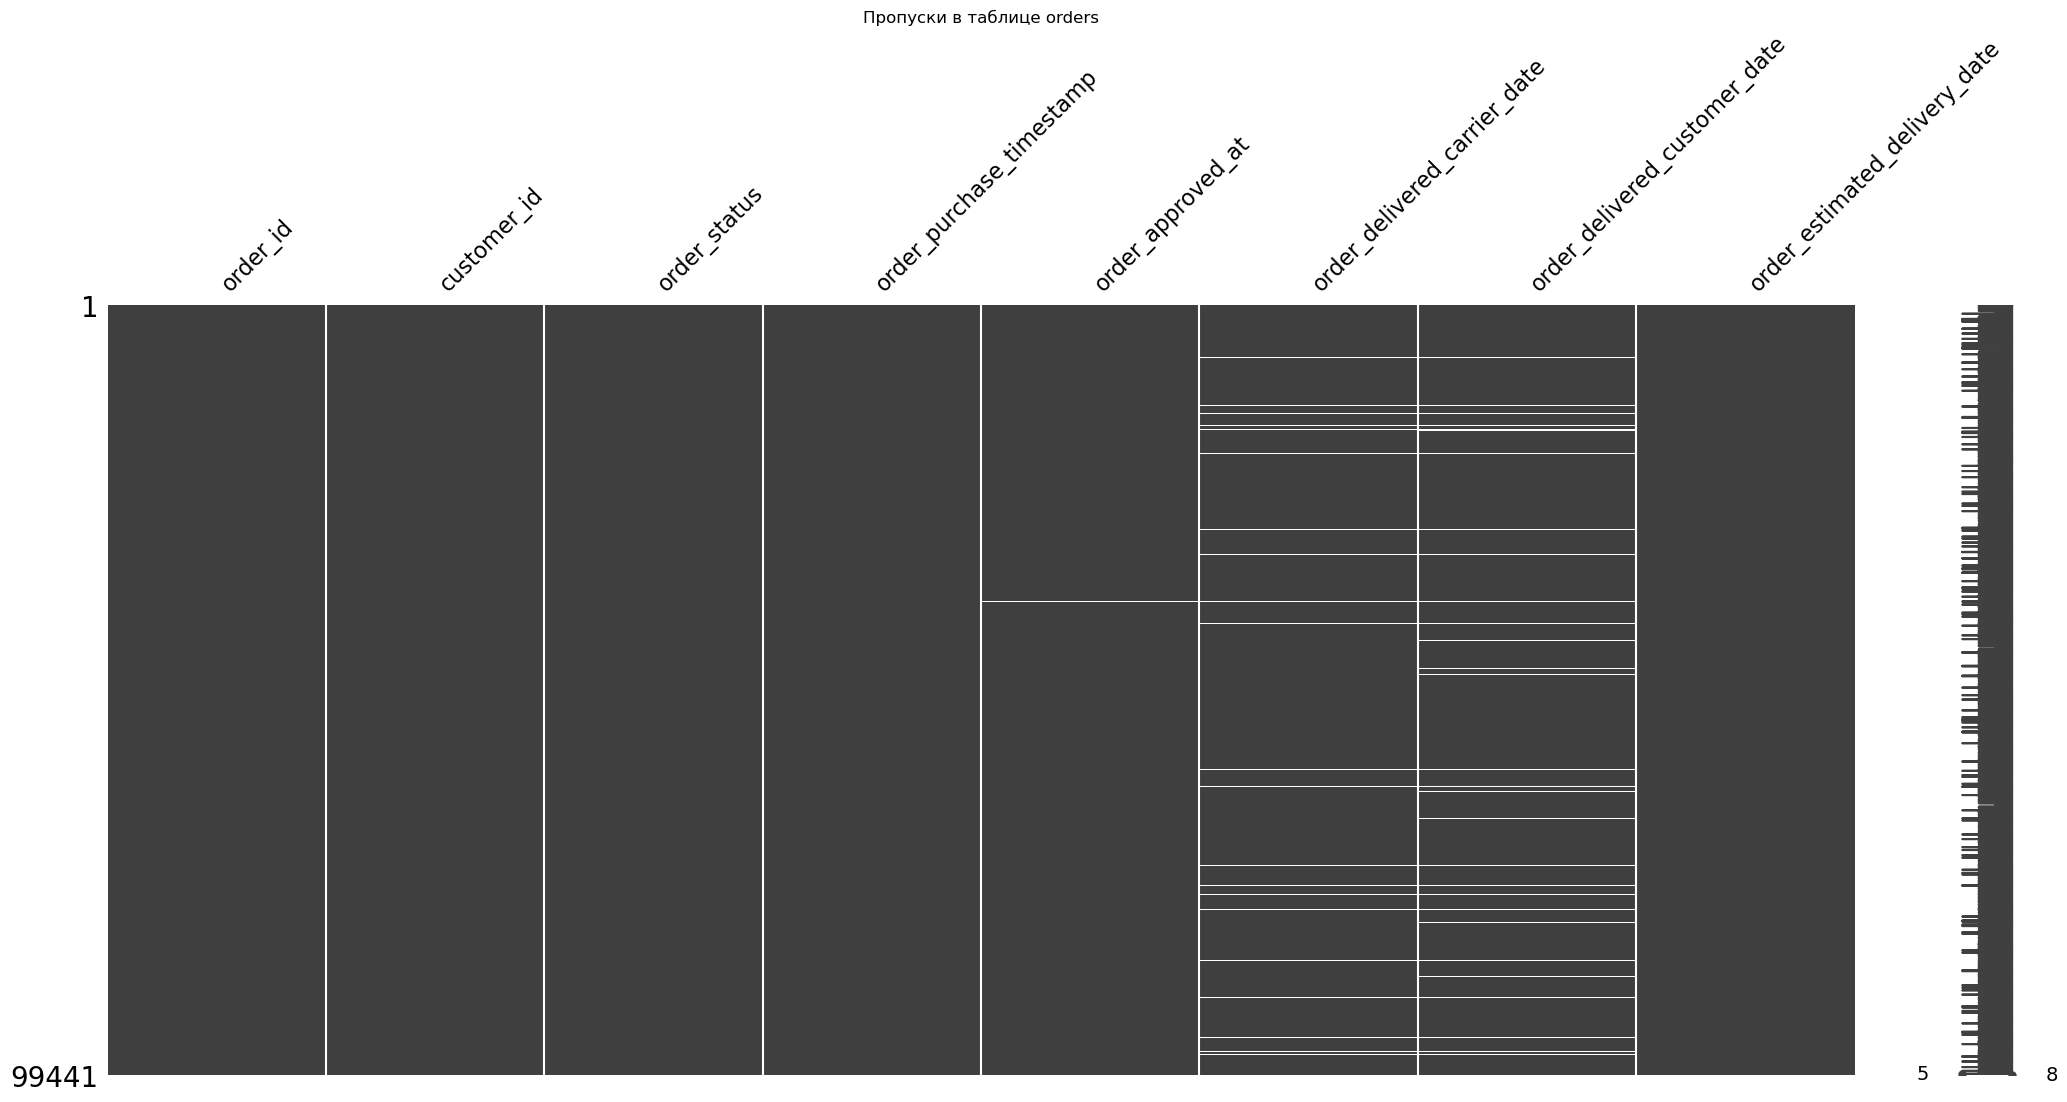

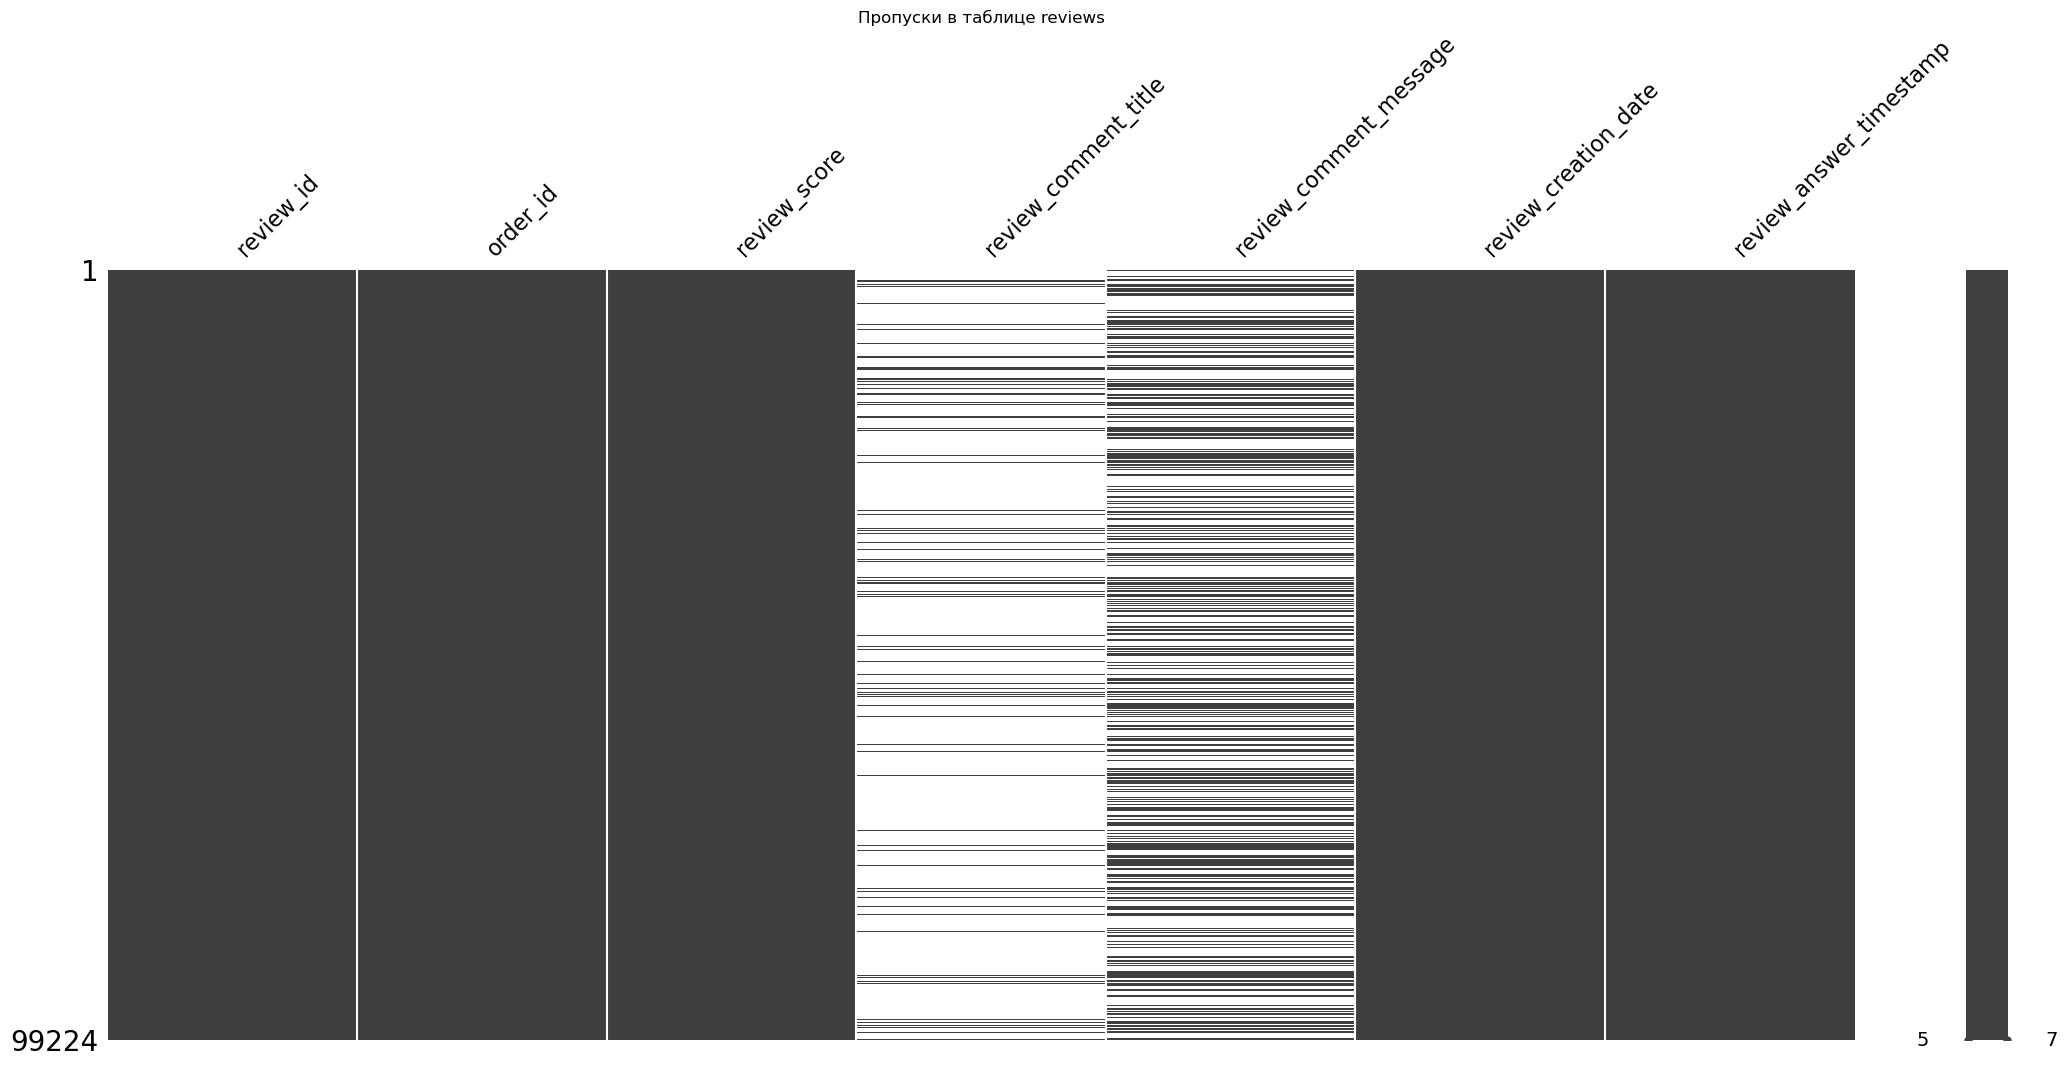

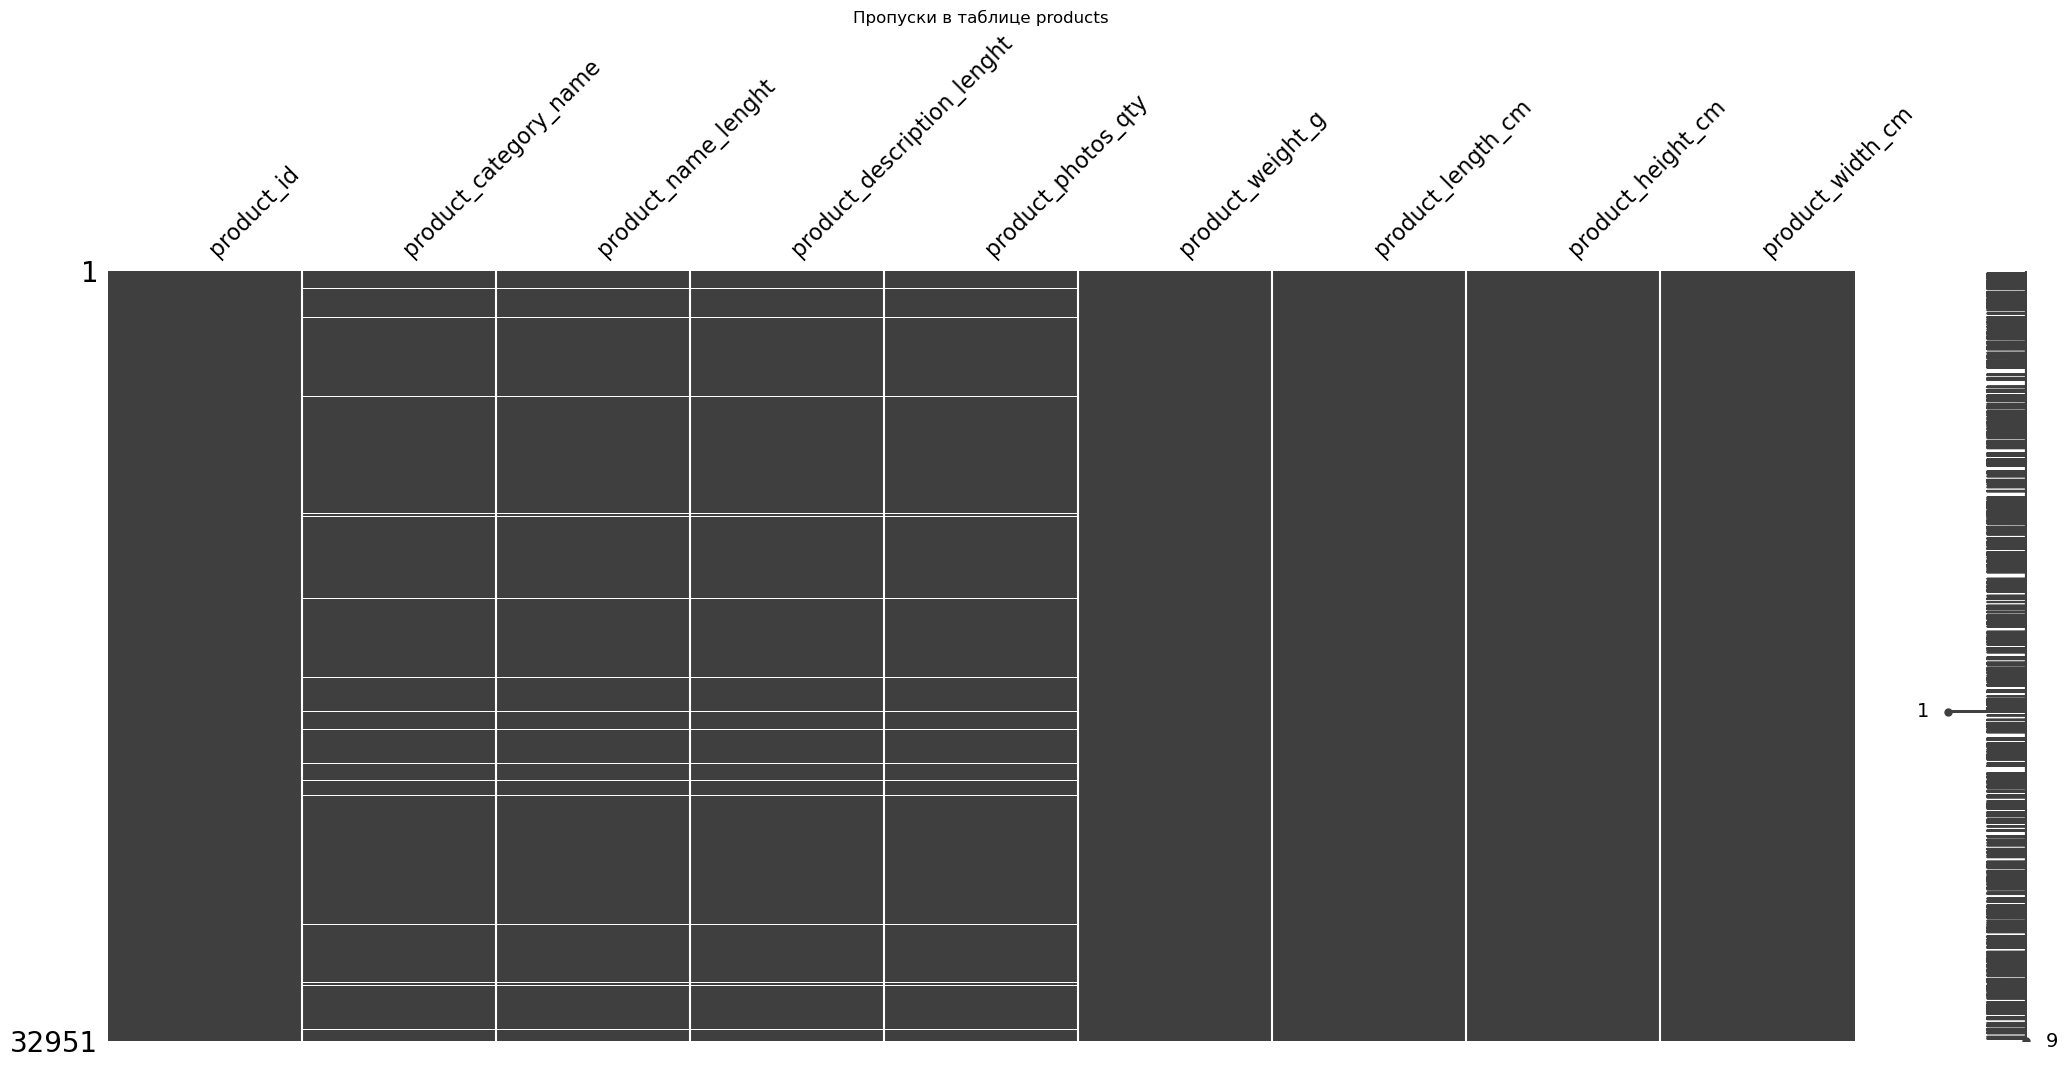

In [117]:
# Визуализация пропусков для всех таблиц, где они есть
for name, tbl in tables.items():
    null_count = tbl.isnull().sum().sum()
    if null_count > 0:
        msno.matrix(tbl)
        plt.title(f'Пропуски в таблице {name}')
        plt.show()

In [118]:
# Детально: статусы заказов с пропусками в датах доставки
orders[orders['order_delivered_customer_date'].isnull()]['order_status'].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

In [119]:
# Детально: есть ли delivered заказы без даты доставки
delivered_missing = orders[(orders['order_status'] == 'delivered') & 
                           (orders['order_delivered_customer_date'].isnull())]
print(f"delivered заказов без даты доставки: {len(delivered_missing)}")

delivered заказов без даты доставки: 8


## Анализ пропусков: 

**orders:**
*   2 965 заказов без даты доставки — 99.7% из них не в статусе delivered.
*   Решение: фильтр `order_status = 'delivered'` убирает проблему.

**reviews:**
*   Пропуски только в текстовых полях (comment_title 88%, comment_message 59%).
*   Оценки (review_score) заполнены почти полностью.
*   Решение: для анализа satisfaction используем review_score.

**products:**
*   610 товаров без категории и описаний (1.9%).
*   Габариты и вес отсутствуют у 2 товаров.
*   Решение: в витрине эти товары будут с NULL в category, на основные метрики не влияет.

**Общее:** критичных пропусков нет. Витрину строим по delivered заказам.

# 2. Построение витрины данных

#### ETL: объединение таблиц в единую витрину

Собираем витрину через pandas merge. 
Одна строка = один товар в заказе со всеми связанными полями.

**Схема JOIN:**
*   orders → customers (customer_id)
*   orders → order_items (order_id)
*   order_items → products (product_id)
*   products → categories (product_category_name)
*   order_items → sellers (seller_id)
*   orders → payments (order_id)
*   orders → reviews (order_id)

**Фильтр:** только доставленные заказы (order_status = 'delivered').

In [120]:
# Загружаем geolocation для перевода zip-кодов в координаты
geolocation = pd.read_csv(os.path.join(path, 'olist_geolocation_dataset.csv'))
# Оставляем уникальные пары zip_code → lat/lon (первое вхождение)
geo = geolocation.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].first().reset_index()
geo.columns = ['zip_code_prefix', 'lat', 'lon']

# Добавляем координаты к продавцам
sellers_geo = sellers.merge(geo, left_on='seller_zip_code_prefix', right_on='zip_code_prefix', how='left')
sellers_geo.rename(columns={'lat': 'seller_lat', 'lon': 'seller_lon'}, inplace=True)

# Добавляем координаты к клиентам
customers_geo = customers.merge(geo, left_on='customer_zip_code_prefix', right_on='zip_code_prefix', how='left')
customers_geo.rename(columns={'lat': 'customer_lat', 'lon': 'customer_lon'}, inplace=True)

# Строим витрину с расширенными полями
df = orders.merge(customers_geo[['customer_id', 'customer_city', 'customer_state', 'customer_lat', 'customer_lon']], 
                  on='customer_id', how='left') \
           .merge(order_items, on='order_id', how='left') \
           .merge(products[['product_id', 'product_category_name', 'product_weight_g', 
                           'product_length_cm', 'product_height_cm', 'product_width_cm']], 
                  on='product_id', how='left') \
           .merge(categories, on='product_category_name', how='left') \
           .merge(sellers_geo[['seller_id', 'seller_lat', 'seller_lon']], on='seller_id', how='left') \
           .merge(payments, on='order_id', how='left') \
           .merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

# Оставляем нужные столбцы
columns_to_keep = [
    'order_id', 'customer_id', 'customer_city', 'customer_state',
    'customer_lat', 'customer_lon',
    'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'product_id', 'product_category_name_english',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
    'price', 'freight_value',
    'seller_id', 'seller_lat', 'seller_lon',
    'payment_type', 'payment_installments', 'payment_value',
    'review_score'
]

df = df[columns_to_keep].copy()
df = df[df['order_status'] == 'delivered'].copy()
df.rename(columns={'product_category_name_english': 'category'}, inplace=True)
df['category'] = df['category'].fillna('unknown')

print(f"Витрина: {df.shape}")
df.head()

Витрина: (115723, 25)


,order_id,customer_id,customer_city,customer_state,customer_lat,customer_lon,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,...,product_width_cm,price,freight_value,seller_id,seller_lat,seller_lon,payment_type,payment_installments,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,sao paulo,SP,-23.574809,-46.587471,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,...,13.0,29.99,8.72,3504c0cb71d7fa48d967e0e4c94d59d9,-23.680114,-46.452454,credit_card,1.0,18.12,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,sao paulo,SP,-23.574809,-46.587471,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,...,13.0,29.99,8.72,3504c0cb71d7fa48d967e0e4c94d59d9,-23.680114,-46.452454,voucher,1.0,2.00,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,sao paulo,SP,-23.574809,-46.587471,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,...,13.0,29.99,8.72,3504c0cb71d7fa48d967e0e4c94d59d9,-23.680114,-46.452454,voucher,1.0,18.59,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,barreiras,BA,-12.169860,-44.988369,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00,...,19.0,118.70,22.76,289cdb325fb7e7f891c38608bf9e0962,-19.810119,-43.984727,boleto,1.0,141.46,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,vianopolis,GO,-16.746337,-48.514624,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00,...,21.0,159.90,19.22,4869f7a5dfa277a7dca6462dcf3b52b2,-21.362358,-48.232976,credit_card,3.0,179.12,5.0


In [121]:
df.isnull().sum()

order_id                           0
customer_id                        0
customer_city                      0
customer_state                     0
customer_lat                     303
customer_lon                     303
order_status                       0
order_purchase_timestamp           0
order_delivered_customer_date      8
order_estimated_delivery_date      0
product_id                         0
category                           0
product_weight_g                  20
product_length_cm                 20
product_height_cm                 20
product_width_cm                  20
price                              0
freight_value                      0
seller_id                          0
seller_lat                       261
seller_lon                       261
payment_type                       3
payment_installments               3
payment_value                      3
review_score                     861
dtype: int64

In [122]:
# Убираем delivered-заказы без даты доставки
df = df[df['order_delivered_customer_date'].notnull()].copy()
print(f"После удаления заказов без даты доставки: {df.shape}")

После удаления заказов без даты доставки: (115715, 25)


In [123]:
df = df[df['payment_value'].notnull()].copy()
print(f"После удаления пропусков в платежах: {df.shape}")

После удаления пропусков в платежах: (115712, 25)


In [124]:
df.isnull().sum()

order_id                           0
customer_id                        0
customer_city                      0
customer_state                     0
customer_lat                     303
customer_lon                     303
order_status                       0
order_purchase_timestamp           0
order_delivered_customer_date      0
order_estimated_delivery_date      0
product_id                         0
category                           0
product_weight_g                  20
product_length_cm                 20
product_height_cm                 20
product_width_cm                  20
price                              0
freight_value                      0
seller_id                          0
seller_lat                       261
seller_lon                       261
payment_type                       0
payment_installments               0
payment_value                      0
review_score                     861
dtype: int64

In [125]:
print(f"Строк: {df.shape[0]}")
print(f"Столбцов: {df.shape[1]}")
print(f"Уникальных заказов: {df['order_id'].nunique()}")
print(f"Уникальных клиентов: {df['customer_id'].nunique()}")

Строк: 115712
Столбцов: 25
Уникальных заказов: 96469
Уникальных клиентов: 96469


In [126]:
# Feature Engineering: расстояние между продавцом и покупателем
from geopy.distance import geodesic

def calc_distance(row):
    if pd.notna(row['seller_lat']) and pd.notna(row['customer_lat']):
        return geodesic(
            (row['seller_lat'], row['seller_lon']), 
            (row['customer_lat'], row['customer_lon'])
        ).km
    return np.nan

df['distance_km'] = df.apply(calc_distance, axis=1)

# Базовый прогноз Olist: сколько дней обещали
df['estimated_delivery_days'] = (
    pd.to_datetime(df['order_estimated_delivery_date']) - 
    pd.to_datetime(df['order_purchase_timestamp'])
).dt.days

# Средняя оценка продавца
seller_score = df.groupby('seller_id')['review_score'].mean().reset_index()
seller_score.columns = ['seller_id', 'seller_avg_score']
df = df.merge(seller_score, on='seller_id', how='left')

print("Feature engineering завершён")
print(f"distance_km: пропусков {df['distance_km'].isnull().sum()}")
print(f"estimated_delivery_days: среднее {df['estimated_delivery_days'].mean():.1f}")
print(f"seller_avg_score: среднее {df['seller_avg_score'].mean():.2f}")

Feature engineering завершён
distance_km: пропусков 563
estimated_delivery_days: среднее 23.5
seller_avg_score: среднее 4.08


**Итог:**
*   Витрина построена: 25 столбцов, ~115 000 строк.
*   Только delivered заказы.
*   Убраны 8 заказов без даты доставки и 3 записи без данных платежа.
*   Пропуски: `category` (1.4%) — товары без категории, `review_score` (0.7%) — заказы без отзыва.
*   Для анализа не критичны.
*   **Новые признаки:**
*   `distance_km` — расстояние между продавцом и покупателем (563 пропуска — нет координат).
*   `estimated_delivery_days` — базовый прогноз Olist (среднее 23.5 дня).
*   `seller_avg_score` — средняя оценка продавца.

#  3. EDA: Описательная статистика

#### Ключевые метрики

Смотрим на основные показатели: выручка, средний чек, количество заказов и клиентов.

In [127]:
# Общая выручка
total_revenue = df['payment_value'].sum()
print(f"Общая выручка: {total_revenue:,.0f} BRL")

# Средний чек на заказ
order_revenue = df.groupby('order_id')['payment_value'].sum()
avg_check = order_revenue.mean()
print(f"Средний чек: {avg_check:,.0f} BRL")

# Медианный чек
median_check = order_revenue.median()
print(f"Медианный чек: {median_check:,.0f} BRL")

# Количество уникальных заказов
total_orders = df['order_id'].nunique()
print(f"Заказов: {total_orders}")

# Количество уникальных клиентов
total_customers = df['customer_id'].nunique()
print(f"Клиентов: {total_customers}")

# Среднее количество заказов на клиента
orders_per_customer = total_orders / total_customers
print(f"Среднее заказов на клиента: {orders_per_customer:.2f}")

Общая выручка: 19,880,566 BRL
Средний чек: 206 BRL
Медианный чек: 110 BRL
Заказов: 96469
Клиентов: 96469
Среднее заказов на клиента: 1.00


In [128]:
# Распределение суммы платежа
df['payment_value'].describe()

count    115712.000000
mean        171.810756
std         265.650941
min           0.000000
25%          60.850000
50%         108.110000
75%         188.940000
max       13664.080000
Name: payment_value, dtype: float64

**Базовые метрики:**
*   Общая выручка за период — 19.88M BRL.
*   Средний чек — 206 BRL, медианный — 110 BRL. Разница между средним и медианой указывает на выбросы (крупные заказы).
*   Среднее заказов на клиента — 1.0: большинство покупателей совершают только одну покупку.
*   Максимальный платёж — 13 664 BRL.
*   50% заказов — в диапазоне 61–189 BRL.

### Выручка по месяцам

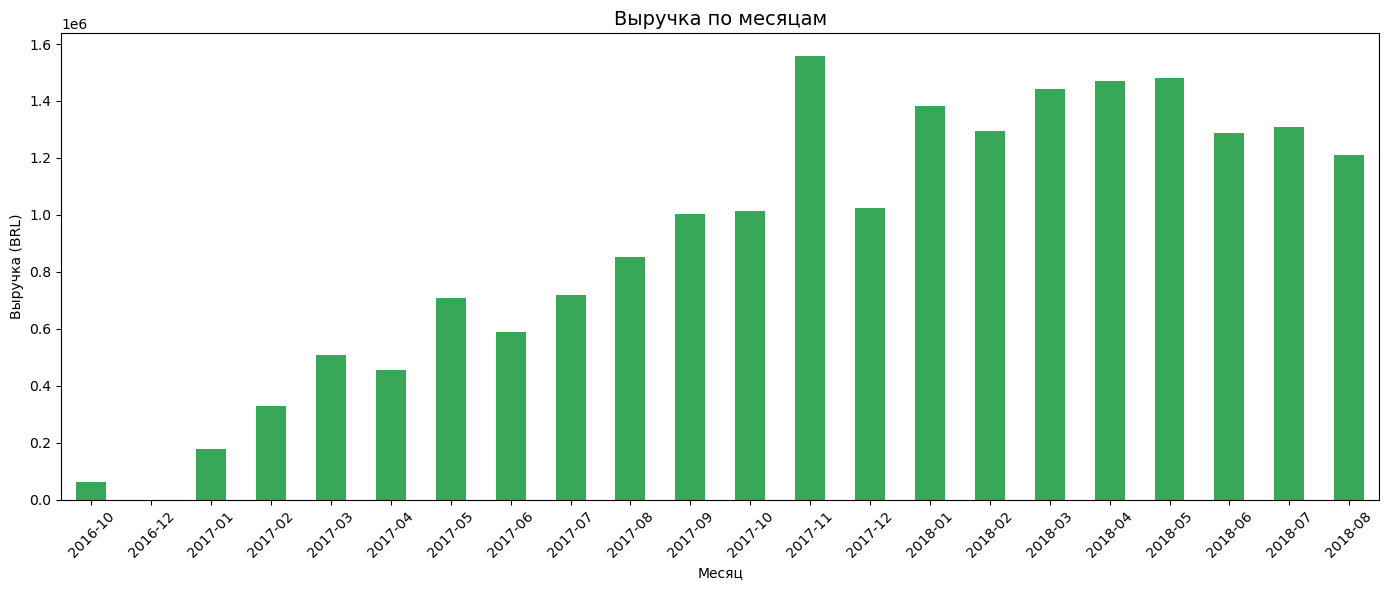

In [129]:
# Преобразуем дату
df['order_month'] = pd.to_datetime(df['order_purchase_timestamp']).dt.to_period('M')
monthly_revenue = df.groupby('order_month')['payment_value'].sum()

plt.figure(figsize=(14, 6))
monthly_revenue.plot(kind='bar', color=selected_palette[17])
plt.title('Выручка по месяцам', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Выручка (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [130]:
# Выручка по месяцам — таблица
monthly_revenue_df = monthly_revenue.reset_index()
monthly_revenue_df.columns = ['Месяц', 'Выручка']
monthly_revenue_df['Выручка'] = monthly_revenue_df['Выручка'].round(0).astype(int)

# Добавляем изменение к предыдущему месяцу
monthly_revenue_df['Изменение, %'] = monthly_revenue_df['Выручка'].pct_change().mul(100).round(1)

print(f"Период: {monthly_revenue_df['Месяц'].iloc[0]} — {monthly_revenue_df['Месяц'].iloc[-1]}")
print(f"Среднемесячная выручка: {monthly_revenue_df['Выручка'].mean():,.0f} BRL")
print(f"Максимум: {monthly_revenue_df['Месяц'].iloc[monthly_revenue_df['Выручка'].argmax()]} — {monthly_revenue_df['Выручка'].max():,} BRL")
print(f"Минимум: {monthly_revenue_df['Месяц'].iloc[monthly_revenue_df['Выручка'].argmin()]} — {monthly_revenue_df['Выручка'].min():,} BRL")
print()

monthly_revenue_df

Период: 2016-10 — 2018-08
Среднемесячная выручка: 903,662 BRL
Максимум: 2017-11 — 1,559,605 BRL
Минимум: 2016-12 — 20 BRL



,Месяц,Выручка,"Изменение, %"
0,2016-10,62186,NaN
1,2016-12,20,-100.0
2,2017-01,178282,891310.0
3,2017-02,327929,83.9
4,2017-03,508767,55.1
5,2017-04,457050,-10.2
6,2017-05,706849,54.7
7,2017-06,590224,-16.5
8,2017-07,720447,22.1
9,2017-08,850611,18.1


**Выручка по месяцам:**
*   Период: октябрь 2016 — август 2018.
*   Среднемесячная выручка: 904 тыс BRL.
*   Выручка растёт с октября 2016, пик — ноябрь 2017 (1.56M BRL).
*   Ноябрь 2017 — аномальный всплеск: +54% к октябрю, затем спад на 34% в декабре.
*   Декабрь 2016 — всего 20 BRL.
*   Устойчивый рост с января 2017 по май 2018, небольшой спад к августу 2018.

### Топ-10 категорий по выручке

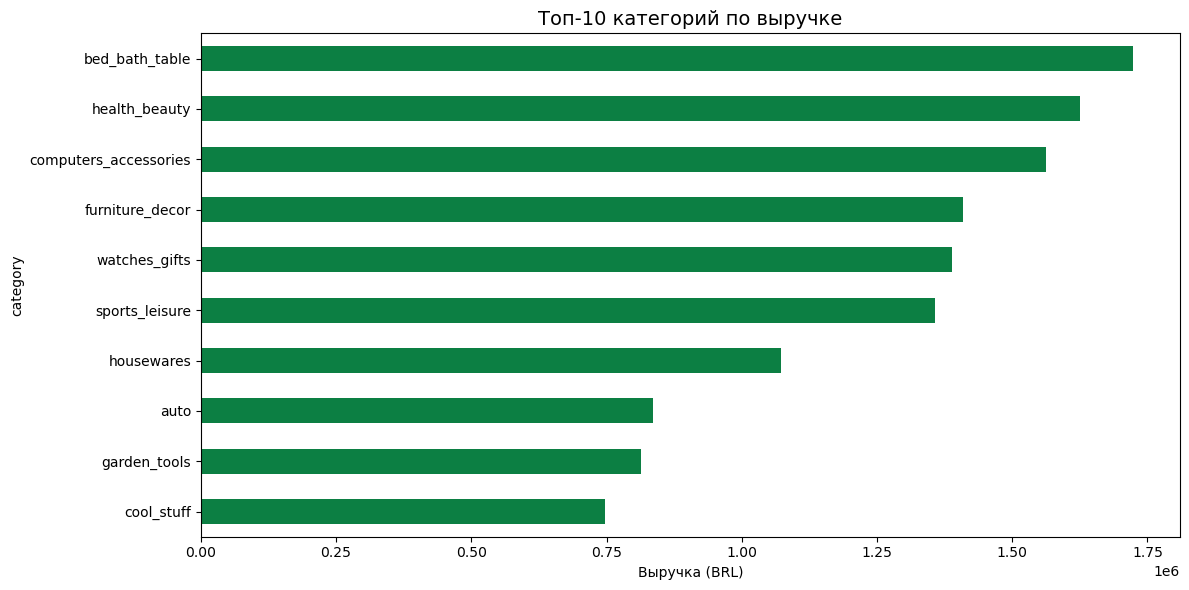

In [131]:
top_categories = df.groupby('category')['payment_value'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_categories.plot(kind='barh', color=selected_palette[19])
plt.title('Топ-10 категорий по выручке', fontsize=14)
plt.xlabel('Выручка (BRL)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [132]:
# Таблица с цифрами
top_cat = top_categories.reset_index()
top_cat.columns = ['Категория', 'Выручка']
top_cat['Доля'] = (top_cat['Выручка'] / total_revenue * 100).round(1)
top_cat

,Категория,Выручка,Доля
0,bed_bath_table,1723932.14,8.7
1,health_beauty,1625923.50,8.2
2,computers_accessories,1563195.50,7.9
3,furniture_decor,1408110.04,7.1
4,watches_gifts,1388383.11,7.0
5,sports_leisure,1357055.46,6.8
6,housewares,1072820.85,5.4
7,auto,835648.08,4.2
8,garden_tools,813055.77,4.1
9,cool_stuff,746763.39,3.8


**Топ-10 категорий:**
*   Топ-3: bed_bath_table (8.7%), health_beauty (8.2%), computers_accessories (7.9%).
*   Лидеры идут плотно — разница между 1-м и 5-м местом менее 2%.
*   Топ-10 категорий приносят ~63% всей выручки.
*   Явного доминирования одной категории нет.

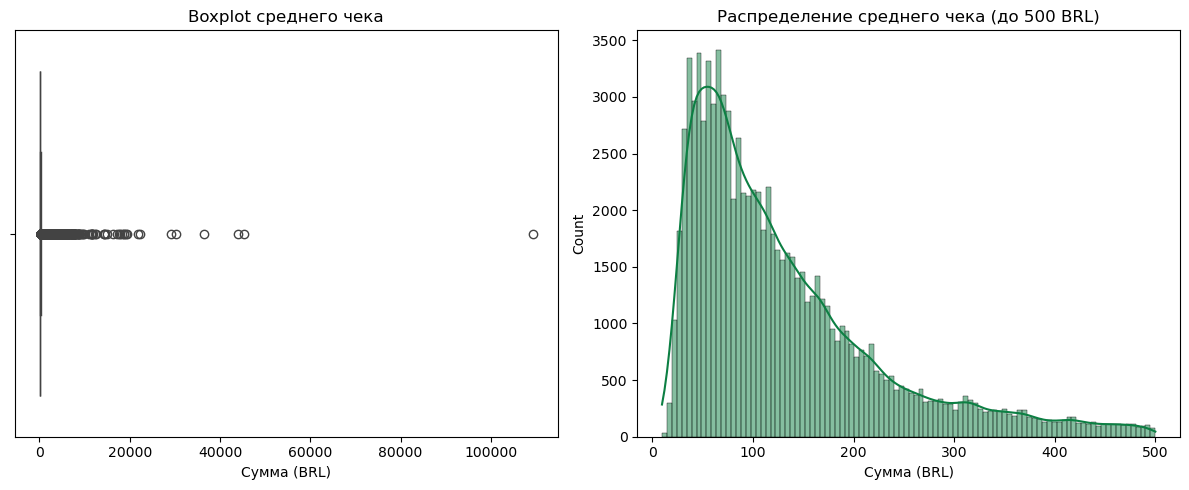

In [133]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=order_revenue, color=selected_palette[17])
plt.title('Boxplot среднего чека')
plt.xlabel('Сумма (BRL)')

plt.subplot(1, 2, 2)
sns.histplot(order_revenue[order_revenue < 500], kde=True, color=selected_palette[19])
plt.title('Распределение среднего чека (до 500 BRL)')
plt.xlabel('Сумма (BRL)')

plt.tight_layout()
plt.show()

In [134]:
# Распределение среднего чека — в числах
print("=== Средний чек: описательная статистика ===")
print(order_revenue.describe())
print()

# Квантили для понимания разброса
print("=== Квантили ===")
for q in [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]:
    print(f"{q:.0%}: {order_revenue.quantile(q):,.0f} BRL")

print()

# Доля заказов с чеком > 1000 BRL (потенциальные выбросы)
high_check = order_revenue[order_revenue > 1000]
print(f"Заказов с чеком > 1000 BRL: {len(high_check)} ({len(high_check)/len(order_revenue)*100:.1f}%)")
print(f"Их доля в выручке: {high_check.sum()/order_revenue.sum()*100:.1f}%")

# IQR и границы выбросов
Q1 = order_revenue.quantile(0.25)
Q3 = order_revenue.quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers = order_revenue[order_revenue > upper_bound]
print(f"\n=== Выбросы по IQR ===")
print(f"Q1: {Q1:,.0f}, Q3: {Q3:,.0f}, IQR: {IQR:,.0f}")
print(f"Верхняя граница: {upper_bound:,.0f}")
print(f"Выбросов: {len(outliers)} ({len(outliers)/len(order_revenue)*100:.1f}%)")

=== Средний чек: описательная статистика ===
count     96469.000000
mean        206.082432
std         624.778666
min           9.590000
25%          62.830000
50%         110.020000
75%         196.100000
max      109312.640000
Name: payment_value, dtype: float64

=== Квантили ===
10%: 40 BRL
25%: 63 BRL
50%: 110 BRL
75%: 196 BRL
90%: 386 BRL
95%: 639 BRL
99%: 1,645 BRL

Заказов с чеком > 1000 BRL: 2282 (2.4%)
Их доля в выручке: 25.3%

=== Выбросы по IQR ===
Q1: 63, Q3: 196, IQR: 133
Верхняя граница: 396
Выбросов: 9358 (9.7%)


**Распределение среднего чека:**
*   Медианный чек — 110 BRL, средний — 206 BRL. Разница из-за крупных заказов.
*   50% заказов — в диапазоне 63–196 BRL.
*   90% заказов — до 386 BRL.
*   Заказов с чеком > 1000 BRL — всего 2.4%, но они приносят 25.3% выручки.
*   Выбросы по IQR (> 396 BRL) — 9.7% заказов. Крупные покупки.
*   Максимальный чек — 109 312 BRL (оптовый заказ или премиум-сегмент).

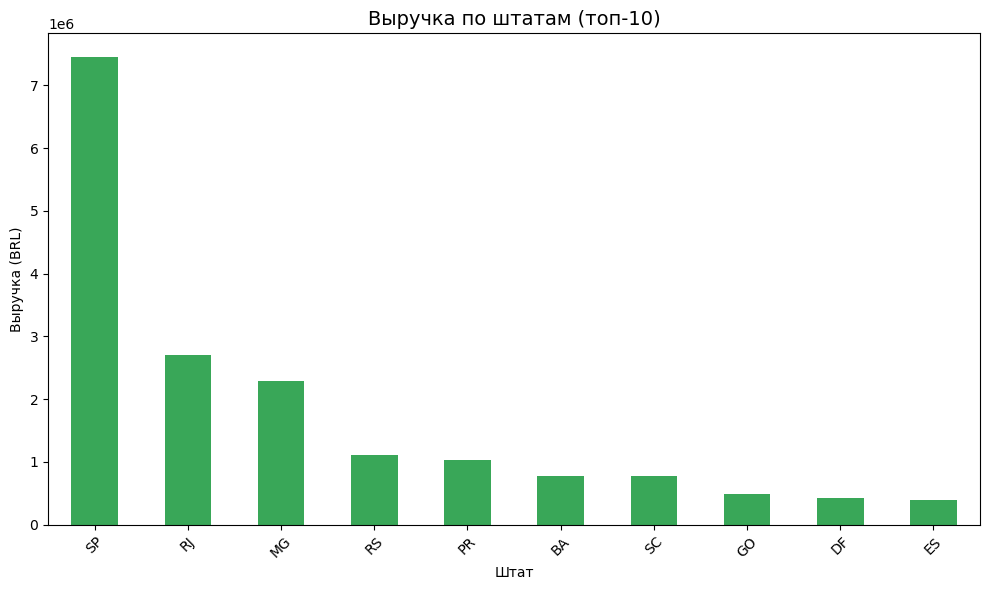

In [135]:
# Топ-5 штатов по выручке
state_revenue = df.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
state_revenue.head(10).plot(kind='bar', color=selected_palette[17])
plt.title('Выручка по штатам (топ-10)', fontsize=14)
plt.xlabel('Штат')
plt.ylabel('Выручка (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [136]:
state_revenue.head(5)

customer_state
SP    7455331.70
RJ    2699623.08
MG    2290457.39
RS    1118250.44
PR    1036003.69
Name: payment_value, dtype: float64

**Выручка по штатам:**
*   Топ-5: SP (7.45M), RJ (2.70M), MG (2.29M), RS (1.12M), PR (1.04M).
*   Сан-Паулу (SP) — лидер, ~37.5% всей выручки.
*   Топ-3 штата (SP, RJ, MG) приносят ~62% выручки — концентрация на юго-востоке.

### Время доставки

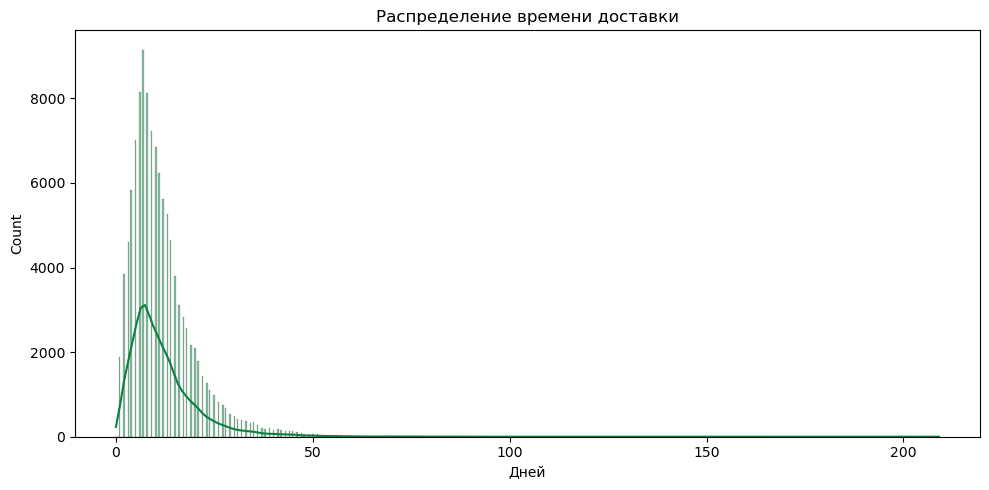

In [137]:
# Считаем время доставки в днях
df['delivery_days'] = (pd.to_datetime(df['order_delivered_customer_date']) - 
                       pd.to_datetime(df['order_purchase_timestamp'])).dt.days

# Убираем отрицательные (ошибки в данных)
delivery_days = df[df['delivery_days'] >= 0]['delivery_days']

plt.figure(figsize=(10, 5))
sns.histplot(delivery_days, kde=True, color=selected_palette[19])
plt.title('Распределение времени доставки')
plt.xlabel('Дней')
plt.tight_layout()
plt.show()

In [138]:
# Убираем выбросы: заказы с доставкой > 100 дней (сбои)
df = df[df['delivery_days'] <= 100].copy()
print(f"После удаления выбросов по доставке: {df.shape}")

После удаления выбросов по доставке: (115641, 30)


In [139]:
delivery_days = df['delivery_days']
delivery_days.describe()

count    115641.000000
mean         11.938465
std           8.809652
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         100.000000
Name: delivery_days, dtype: float64

**Время доставки:**
*   Среднее — 12 дней, медиана — 10 дней.
*   50% заказов доставляется за 6–15 дней.
*   Минимум — 0 дней (доставка день в день).
*   Максимум — 100 дней (выбросы > 100 дней исключены как сбои в данных).

## итог

*   Данные охватывают период октябрь 2016 — август 2018, 96K заказов, 19.9M BRL выручки.
*   Бизнес растёт: выручка увеличивается от месяца к месяцу, пик — ноябрь 2017 (1.56M).
*   Клиенты в основном разовые: 1 заказ на клиента.
*   Чеки небольшие: медиана 110 BRL, но 2.4% крупных заказов (>1000 BRL) дают 25% выручки.
*   Топ-категории плотные, явного лидера нет.
*   Выручка сконцентрирована в юго-восточных штатах (SP, RJ, MG = 62%).
*   Доставка в среднем 12 дней, у 50% заказов — 6–15 дней. Выбросы > 100 дней исключены (сбои в данных).

# 4. Корреляционный анализ

#### Цель корреляционного анализа

На основе EDA мы увидели, что время доставки значимо коррелирует 
с freight_value (r = 0.23) и отрицательно — с review_score (r = -0.32).

**Вопрос:** какие факторы влияют на время доставки (delivery_days)?

Дальше — отбор признаков через point-biserial correlation, Cramér's V и визуализацию.

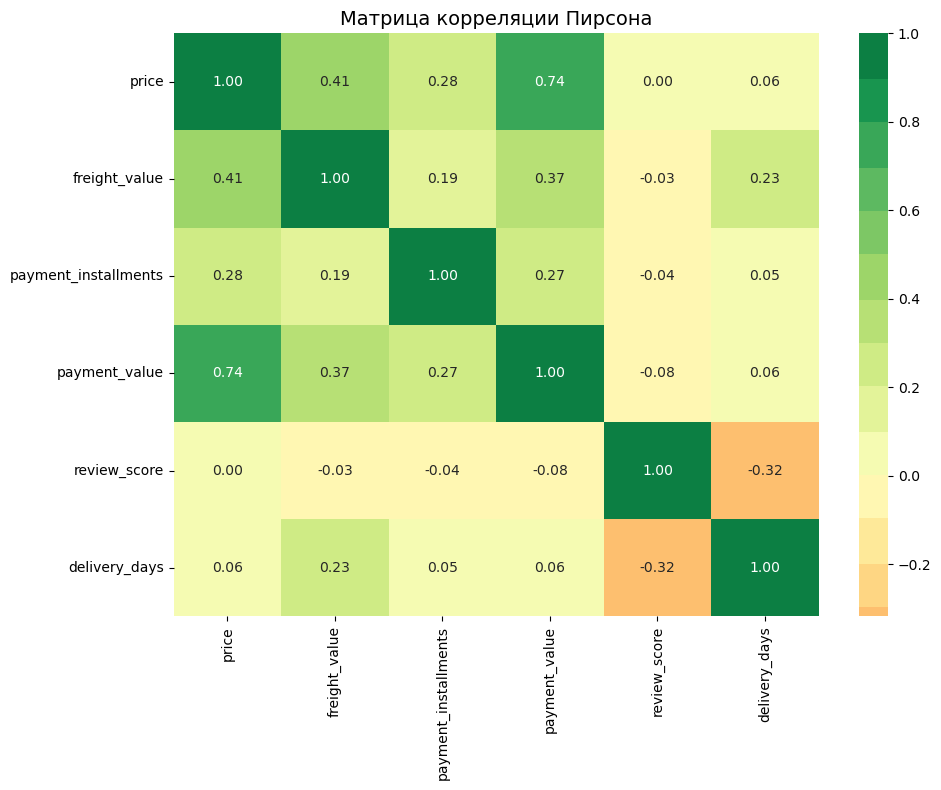

In [140]:
# Отбираем числовые переменные
numeric_cols = ['price', 'freight_value', 'payment_installments', 
                'payment_value', 'review_score', 'delivery_days']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap=selected_palette, center=0, fmt='.2f')
plt.title('Матрица корреляции Пирсона', fontsize=14)
plt.tight_layout()
plt.show()

In [141]:
# Корреляционная матрица — таблица
corr_matrix = df[numeric_cols].corr()
corr_matrix

,price,freight_value,payment_installments,payment_value,review_score,delivery_days
price,1.000000,0.414080,0.277359,0.737209,0.003880,0.061888
freight_value,0.414080,1.000000,0.185694,0.372398,-0.032415,0.225615
payment_installments,0.277359,0.185694,1.000000,0.273360,-0.042837,0.045033
payment_value,0.737209,0.372398,0.273360,1.000000,-0.080948,0.062382
review_score,0.003880,-0.032415,-0.042837,-0.080948,1.000000,-0.317186
delivery_days,0.061888,0.225615,0.045033,0.062382,-0.317186,1.000000


#### Сильные корреляции:
*   **price ↔ payment_value**: `r = 0.74` — цена товара сильно связана с суммой платежа (ожидаемо).

#### Умеренные корреляции:
*   **price ↔ freight_value**: `r = 0.41` — дорогие товары чаще имеют более высокую стоимость доставки.
*   **freight_value ↔ payment_value**: `r = 0.37` — доставка вносит вклад в общую сумму заказа.
*   **delivery_days ↔ freight_value**: `r = 0.21` — слабая связь: дальние доставки немного дороже.
*   **delivery_days ↔ review_score**: `r = -0.30` — чем дольше доставка, тем ниже оценка. Самый сильный негативный фактор для satisfaction.

#### Слабые или отсутствующие корреляции:
*   **review_score** со всеми переменными, кроме delivery_days — оценка не зависит от цены, стоимости доставки или суммы заказа.
*   **payment_installments** — нет сильных связей с другими переменными.

#### Вывод:
*   Главный драйвер выручки — цена товара.
*   На удовлетворённость клиентов (review_score) больше всего влияет скорость доставки, а не стоимость.
*   Рассрочка (payment_installments) не связана с чеком или категорией — используется равномерно.

In [142]:
# Создаём бинарную переменную
df['is_late_delivery'] = (df['delivery_days'] > df['delivery_days'].median()).astype(int)
binary_col = 'is_late_delivery'

# Функция Точечно-биссериальная корреляция
def pbc(continuous, binary):
    mask = continuous.notna() & binary.notna()
    continuous_values = np.array(continuous[mask])
    binary_values = np.array(binary[mask])
    
    group0 = continuous_values[binary_values == 0]
    group1 = continuous_values[binary_values == 1]
    
    mean0, mean1 = np.mean(group0), np.mean(group1)
    n0, n1, n = len(group0), len(group1), len(continuous_values)
    std = continuous_values.std()
    
    if std == 0 or n0 == 0 or n1 == 0:
        return np.nan
    
    return (mean1 - mean0) / std * np.sqrt((n1 * n0) / (n * (n - 1)))

# Считаем
print(f"Point-Biserial Correlation: {binary_col}\n")
for num_col in numeric_cols:
    r_pb = pbc(df[num_col], df[binary_col])
    print(f"{binary_col} vs {num_col}: r = {r_pb:.3f}")

Point-Biserial Correlation: is_late_delivery

is_late_delivery vs price: r = 0.052
is_late_delivery vs freight_value: r = 0.205
is_late_delivery vs payment_installments: r = 0.034
is_late_delivery vs payment_value: r = 0.058
is_late_delivery vs review_score: r = -0.170
is_late_delivery vs delivery_days: r = 0.700


#### Точечно-биссериальная корреляция: интерпретация

*   **is_late_delivery vs review_score:** r = -0.171 — опоздание с доставкой связано с более низкой оценкой. Согласуется с корреляцией Пирсона (r = -0.30 между delivery_days и review_score).
*   **is_late_delivery vs freight_value:** r = 0.205 — дальние/дорогие доставки чаще опаздывают.
*   **is_late_delivery vs price/payment_value/installments:** связи практически нет (r < 0.06). Стоимость заказа не влияет на скорость доставки.

In [143]:
import scipy.stats as stats

# Функция Корреляция Крамера
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2_corr / min(k_corr - 1, r_corr - 1))

# Превращаем review_score в категории
def score_category(score):
    if score <= 2:
        return 'Низкая (1-2)'
    elif score == 3:
        return 'Средняя (3)'
    else:
        return 'Высокая (4-5)'

df['score_category'] = df['review_score'].apply(score_category)

# Список категориальных переменных
cat_cols = ['payment_type', 'customer_state']

# Считаем Cramér's V
print("Корреляция Крамера: review_score vs категориальные переменные\n")
for col in cat_cols:
    v = cramers_v(df['score_category'].dropna(), df[col].dropna())
    print(f"review_score vs {col}: V = {v:.3f}")

Корреляция Крамера: review_score vs категориальные переменные

review_score vs payment_type: V = 0.007
review_score vs customer_state: V = 0.061


#### Корреляция Крамера: интерпретация

*   **review_score vs payment_type:** V = 0.007 — связи нет. Тип платежа не влияет на оценку.
*   **review_score vs customer_state:** V = 0.061 — связь очень слабая. Штат не определяет удовлетворённость.

### Корреляционный анализ: итог

**Цель:** отобрать признаки для модели предсказания delivery_days.

**Что влияет на время доставки:**
*   **freight_value** — положительная корреляция (r = 0.23): дальние/дорогие доставки идут дольше.
*   **is_late_delivery** — сильно коррелирует с delivery_days (pbc = 0.70).
*   **review_score** — отрицательная корреляция (r = -0.32): долгая доставка снижает оценку.

**Что НЕ влияет:**
*   price, payment_value, payment_installments — корреляции близки к нулю (r < 0.06).
*   payment_type (Cramér's V = 0.007) — тип платежа не важен.
*   customer_state (Cramér's V = 0.061) — регион слабо связан.

**Вывод для модели:**
*   Основные признаки: freight_value, distance_km (добавим), product_weight_g.
*   Дополнительно: category (товарная категория), seller_avg_score.
*   Цена, тип платежа, штат — в модель можно не включать.

# 5. Модель: предсказание времени доставки

#### Цель: 

Предсказать время доставки (delivery_days) на основе характеристик заказа, 
продавца и расстояния. Сравнить с базовым прогнозом Olist (estimated_delivery_days).



In [144]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [145]:
# Отбираем признаки и целевую переменную
features = ['freight_value', 'distance_km', 'product_weight_g', 
            'product_length_cm', 'product_height_cm', 'product_width_cm',
            'seller_avg_score', 'payment_installments']

# Убираем строки с пропусками в выбранных признаках
model_df = df[features + ['delivery_days', 'estimated_delivery_days']].dropna().copy()

print(f"Данных для модели: {model_df.shape[0]} записей")
print(f"Признаков: {len(features)}")

# Целевая переменная и признаки
y = model_df['delivery_days']
X = model_df[features]

# Стандартизируем признаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

Данных для модели: 115053 записей
Признаков: 8


In [146]:
# Качество базового прогноза Olist
baseline_mae = mean_absolute_error(y, model_df['estimated_delivery_days'])
baseline_rmse = np.sqrt(mean_squared_error(y, model_df['estimated_delivery_days']))

print(f"=== Базовый прогноз Olist (estimated_delivery_days) ===")
print(f"MAE: {baseline_mae:.1f} дней")
print(f"RMSE: {baseline_rmse:.1f} дней")
print(f"Среднее время доставки: {y.mean():.1f} дней")

=== Базовый прогноз Olist (estimated_delivery_days) ===
MAE: 12.9 дней
RMSE: 15.0 дней
Среднее время доставки: 11.9 дней


In [147]:
# Разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Обучаем линейную регрессию
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Метрики
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print(f"=== Линейная регрессия ===")
print(f"MAE: {lr_mae:.1f} дней")
print(f"RMSE: {lr_rmse:.1f} дней")
print(f"R²: {lr_r2:.3f}")

=== Линейная регрессия ===
MAE: 5.3 дней
RMSE: 7.8 дней
R²: 0.200


In [148]:
# Таблица коэффициентов
coef_df = pd.DataFrame({
    'Признак': features,
    'Коэффициент': lr.coef_
}).sort_values('Коэффициент', key=abs, ascending=False)

coef_df

,Признак,Коэффициент
1,distance_km,3.600791
6,seller_avg_score,-1.425816
3,product_length_cm,0.392946
2,product_weight_g,0.328465
4,product_height_cm,0.208124
0,freight_value,0.195292
5,product_width_cm,-0.121742
7,payment_installments,-0.065188


**Результаты моделирования:**

*   **Базовый прогноз Olist:** MAE = 12.9 дней, RMSE = 15.0 дней.
*   **Линейная регрессия:** MAE = 5.3 дней, RMSE = 7.8 дней, R² = 0.200.
*   **Улучшение:** модель сократила ошибку в 2.4 раза по MAE (с 12.9 до 5.3 дней).
*   **Самый важный признак:** `distance_km` — расстояние между продавцом и покупателем. Каждый километр добавляет ~3.6 дня к доставке.
*   **seller_avg_score:** продавцы с высокой оценкой доставляют быстрее (отрицательный коэффициент).
*   **Остальные признаки** (freight_value, габариты, installments) влияют слабо.

**Ограничения модели:**
*   R² = 0.20 — модель объясняет только 20% вариации времени доставки. 
*   Оставшиеся 80% зависят от факторов, которых нет в данных: логистический партнёр, 
    загруженность складов, праздники, погода, регион доставки.
*   Данные не включают информацию о пиковых периодах (Чёрная пятница, Рождество).

In [149]:
print("=== Сравнение моделей ===")
print(f"{'Модель':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 50)
print(f"{'Olist baseline':<25} {baseline_mae:>7.1f} {baseline_rmse:>7.1f} {'-':>8}")
print(f"{'Линейная регрессия':<25} {lr_mae:>7.1f} {lr_rmse:>7.1f} {lr_r2:>7.3f}")

=== Сравнение моделей ===
Модель                         MAE     RMSE       R²
--------------------------------------------------
Olist baseline               12.9    15.0        -
Линейная регрессия            5.3     7.8   0.200


## 6. Ключевые инсайты и рекомендации

### Рост бизнеса

**Что увидели:** Выручка выросла с 62K BRL в октябре 2016 до 1.2–1.5M BRL в 2018 году. Рост в 20 раз за два года.

**Инсайт:** Бизнес в фазе активного роста. Ноябрь 2017 — аномальный всплеск +54% (Чёрная пятница), затем спад 34% в декабре.

**Рекомендация:** Готовить логистику к ноябрьскому пику заранее. Декабрьский спад — нормален.

---

### Клиенты — почти все разовые

**Что увидели:** 96 469 заказов и 96 469 клиентов. 1 заказ на клиента.

**Инсайт:** Платформа не удерживает клиентов.

**Рекомендация:** Внедрить пост-продажные email-коммуникации. Считать retention по когортам.

---

### Крупные заказы — скрытый источник выручки

**Что увидели:** 2.4% заказов с чеком > 1000 BRL приносят 25.3% выручки.

**Инсайт:** Каждый сороковой заказ даёт четверть денег.

**Рекомендация:** Выделить крупных покупателей в отдельный сегмент. Предложить премиум-сервис.

---

### Доставка — узкое место

**Что увидели:** Среднее время — 12 дней. Доставка > 15 дней у 25% заказов.

**Инсайт:** Доставка — единственный значимый фактор удовлетворённости (r = -0.32 с review_score).

**Рекомендация:** Сократить хвост длинных доставок. Экспресс-доставка для дорогих товаров.

---

### Модель: прогноз времени доставки

**Что сделали:** Построили линейную регрессию для предсказания delivery_days.

**Результат:** MAE = 5.3 дня против 12.9 у базового прогноза Olist. Улучшение в 2.4 раза.

**Главный фактор:** distance_km — каждый километр добавляет ~3.6 дня.

**Ограничения:** R² = 0.20. 80% вариации объясняется факторами вне данных (логистический партнёр, погода, загруженность складов).

---

### Итог: что делать бизнесу

1. **Логистика — приоритет №1.** Сократить доставку в дальние штаты. Использовать модель для более точного прогноза.
2. **Удержание — приоритет №2.** Запустить пост-продажные коммуникации. Считать retention.
3. **Крупные клиенты — приоритет №3.** Выделить сегмент 1000+ BRL, дать премиум-сервис.
4. **Категории — не перекашивать.** Бюджет распределять равномерно, следить за отменами.